<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# from cellmender.utils.visualization_utils import plot_cross_species_histogram

# Compare CellBender vs. cellmender

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [3]:
dataset_name = "simulation1_small_noise"  # options: pbmc8k, hgmm12k, simulation1_small_noise, simulation2_no_noise, simulation3_all_noise, custom
rerun_tools = True  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = True  # for CellBender and scAR
threads = 8  # for cellmender and CellBender (if use_cuda=False)

yaml_file = os.path.join(cellmender_dir, "notebooks", "config", f"{dataset_name}.yaml")  # for a custom dataset, make a new yaml file in this location with the desired config - see example template at notebooks/config/custom.yaml

In [ ]:
# load yaml
cfg = cm_utils.load_dataset_yaml(yaml_file)

# create directories for data, output
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

# raw adata
adata_path_raw = f"{data_dir}/{cfg['adata_raw_file_name']}"
if not os.path.exists(adata_path_raw) and cfg["adata_raw_url"] is not None:
    !wget -O {adata_path_raw} {cfg["adata_raw_url"]}

# raw and filtered matrix tar files
matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
os.makedirs(matrix_tar_files_dir, exist_ok=True)

raw_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['raw_tar_file_dir_suffix']}"
if not os.path.exists(raw_tar_file_dir) and cfg["raw_tar_url"] is not None and rerun_tools:
    raw_tar_path = os.path.join(matrix_tar_files_dir, cfg["raw_tar_file_name"])
    !wget -O {raw_tar_path} {cfg["raw_tar_url"]}
    !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}

filtered_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['filtered_tar_file_dir_suffix']}"
if not os.path.exists(filtered_tar_file_dir) and cfg["filtered_tar_url"] is not None and rerun_tools:
    filtered_tar_path = os.path.join(matrix_tar_files_dir, cfg["filtered_tar_file_name"])
    !wget -O {filtered_tar_path} {cfg["filtered_tar_url"]}
    !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

sequencing_technology = cfg["sequencing_technology"]

# set file paths for tools
adata_path_cellmender = f"{data_dir}/{cfg['adata_path_cellmender_name']}"
cellmender_log_file = os.path.join(data_dir, "cellmender.log")

adata_path_cellbender = f"{data_dir}/{cfg['adata_path_cellbender_name']}"
adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")
cellbender_ckpt = os.path.join(data_dir, "cellbender_ckpt.tar.gz")

soupx_out_prefix = f"{data_dir}/{cfg['soupx_out_prefix_name']}"
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"

decontx_out_prefix = f"{data_dir}/{cfg['decontx_out_prefix_name']}"

adata_path_scar = f"{data_dir}/{cfg['adata_path_scar_name']}"


if dataset_name == "hgmm12k":    
    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    # # check if raw_tar_file_dir is empty or doesn't exist
    # if rerun_tools and (not os.path.exists(raw_tar_file_dir) or len(os.listdir(raw_tar_file_dir)) == 0) or (not os.path.exists(filtered_tar_file_dir) or len(os.listdir(filtered_tar_file_dir)) == 0):
    adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
    umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=cfg["expected_cells"], show=False)
    adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cm_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix

if dataset_name.startswith("simulation"):
    # load simulation config
    with open(yaml_file, "r") as f:
        config = yaml.safe_load(f)

    # simulate data
    if not os.path.exists(adata_path_raw) or overwrite:
        adata_raw = simulate_cells(
            G=config["G"],
            k=config["k"],
            markers_per_type=config["markers_per_type"],
            marker_boost=config["marker_boost"],
            type_proportions=config["type_proportions"],
            empty_prob=config["empty_prob"],
            alpha=config["alpha"],
            expected_cell_size=config["expected_cell_size"],
            rng_seed=42,
        )
        adata_raw.write_h5ad(adata_path_raw)
    else:
        adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)

    paths = cm_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=True)

    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix


# lay out parameters
model_pkl = cfg["model_pkl"]
cellmender_max_iter = cfg["cellmender_max_iter"]
cellmender_beta = cfg["cellmender_beta"]
cellmender_init_alpha = cfg["cellmender_init_alpha"]
cellbender_epochs = cfg["cellbender_epochs"]
cellbender_fpr = cfg["cellbender_fpr"]
cellbender_zdim = cfg["cellbender_zdim"]
cellbender_expected_cells = cfg["cellbender_expected_cells"]
cellbender_total_droplets = cfg["cellbender_total_droplets"]
scar_epochs = cfg["scar_epochs"]
scar_prob = cfg["scar_prob"]
expected_cells = cfg["expected_cells"]
cs_empty_threshold = cfg["cs_empty_threshold"]
min_genes = cfg["min_genes"]
min_cells = cfg["min_cells"]
umi_top_percentile_to_remove = cfg["umi_top_percentile_to_remove"]
fraction_doublet = cfg["fraction_doublet"]
unique_genes_top_percentile_to_remove = cfg["unique_genes_top_percentile_to_remove"]
mt_gene_percentile_to_remove = cfg["mt_gene_percentile_to_remove"]
max_mt_percentage = cfg["max_mt_percentage"]
n_top_genes = cfg["n_top_genes"]
n_pcs = cfg["n_pcs"]
n_neighbors = cfg["n_neighbors"]
leiden_resolution = cfg["leiden_resolution"]
marker_genes = cfg["marker_genes"]

cellmender_matrix_url = cfg["cellmender_matrix_url"]
cellbender_matrix_url = cfg["cellbender_matrix_url"]
cellbender_matrix_filtered_url = cfg["cellbender_matrix_filtered_url"]
cellbender_ckpt_url = cfg["cellbender_ckpt_url"]
soupx_matrix_url = cfg["soupx_matrix_url"]
decontx_matrix_url = cfg["decontx_matrix_url"]
scar_matrix_url = cfg["scar_matrix_url"]

01:35:46 - INFO - Loading adata from '/home/jrich/Desktop/cellmender/notebooks/data/simulation1_small_noise/adata_raw.h5ad'


Found existing 10x files in '/home/jrich/Desktop/cellmender/notebooks/data/simulation1_small_noise/matrix_tar_files/raw_gene_bc_matrices/genome'. Skipping write.
Found existing 10x files in '/home/jrich/Desktop/cellmender/notebooks/data/simulation1_small_noise/matrix_tar_files/filtered_gene_bc_matrices/genome'. Skipping write.


## Raw

In [5]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

01:35:46 - INFO - Loading adata from '/home/jrich/Desktop/cellmender/notebooks/data/simulation1_small_noise/adata_raw.h5ad'


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (200): 113.00


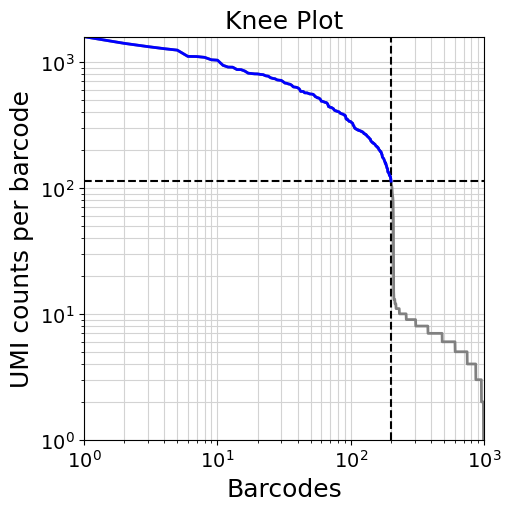

In [6]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

In [8]:
if dataset_name == "hgmm12k" and 'celltype' not in adata_raw.obs:
    adata_raw.obs['hg19_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'hg19'].X.sum(axis=1)).ravel()
    adata_raw.obs['mm10_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'mm10'].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs['hg19_total_counts'] >= adata_raw.obs['mm10_total_counts'], 'hg19', 'mm10')  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    adata_raw = cm_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=fraction_doublet, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, "hgmm12k_doublet_detection.png"), show=False)

Gene_1178: 27
Gene_720: 14
Gene_1611: 13
Gene_554: 13
Gene_1733: 12
Gene_644: 12
Gene_1380: 12
Gene_898: 12
Gene_1389: 11
Gene_1071: 11


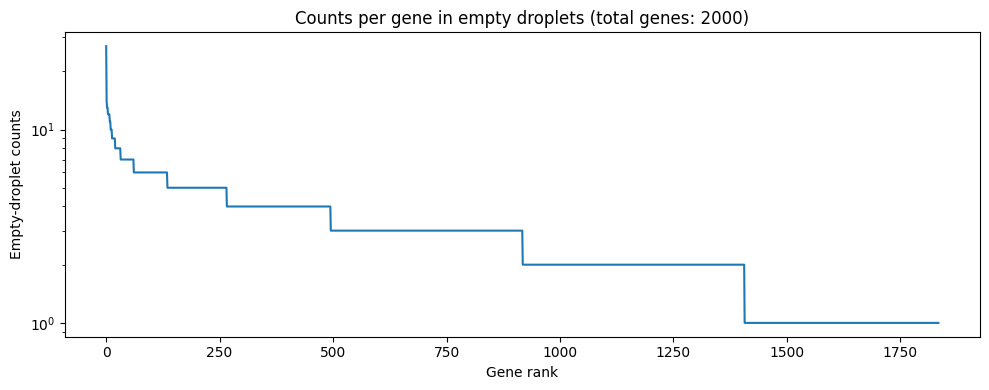

In [9]:
cm_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cm_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

## cellmender

In [10]:
%%time
if not os.path.exists(adata_path_cellmender) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata.obs.columns:
        adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
    _ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, beta=cellmender_beta, freeze_ambient_profile=True, init_alpha = cellmender_init_alpha, max_iter=cellmender_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellmender_log_file)

CPU times: user 32 μs, sys: 2 μs, total: 34 μs
Wall time: 40.8 μs


In [11]:
adata_cellmender = ad.read_h5ad(adata_path_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()
adata_cellmender.var_names_make_unique()
print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellmender)}")

Counts are less than or equal check for CellMender: True


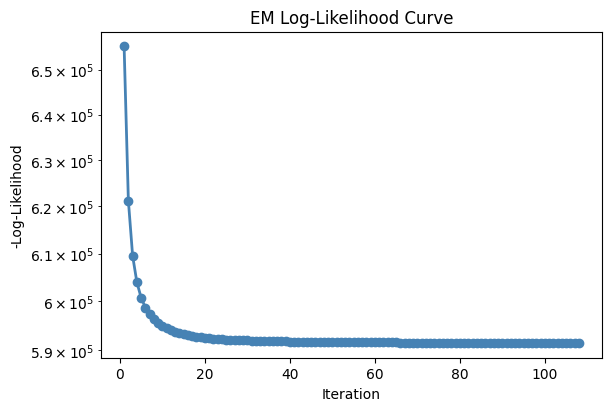

UMI cutoff for expected cells (200): 113.00
UMI cutoff for expected cells (200): 113.00


,cellid,celltype,is_empty,ambient_fraction,lib_size,cell_ambient_fraction,alpha_hat,z_hat,total_counts_raw,total_counts_denoised
Cell_3,21,Type_20,False,0.025806,557.430111,0.9,1.000000e-12,19,155,155.000000
Cell_7,2,Type_1,False,0.012101,1921.140850,0.9,1.747355e-11,3,909,909.000000
Cell_14,15,Type_14,False,0.072000,404.065566,0.9,1.000000e-12,14,125,125.000000
Cell_27,2,Type_1,False,0.015924,854.260361,0.9,7.675496e-02,3,314,289.898942
Cell_30,18,Type_17,False,0.079646,444.017120,0.9,1.000000e-12,16,113,113.000000
Cell_31,15,Type_14,False,0.016566,1505.612300,0.9,1.000000e-12,14,664,664.000000
Cell_32,3,Type_2,False,0.017953,1199.289379,0.9,1.000000e-12,4,556,556.000000
Cell_34,10,Type_9,False,0.058537,668.190620,0.9,1.000000e-12,10,205,205.000000
Cell_35,23,Type_22,False,0.018957,1659.746515,0.9,7.153378e-12,21,633,633.000000
Cell_42,13,Type_12,False,0.024138,843.090172,0.9,1.000000e-12,12,289,289.000000


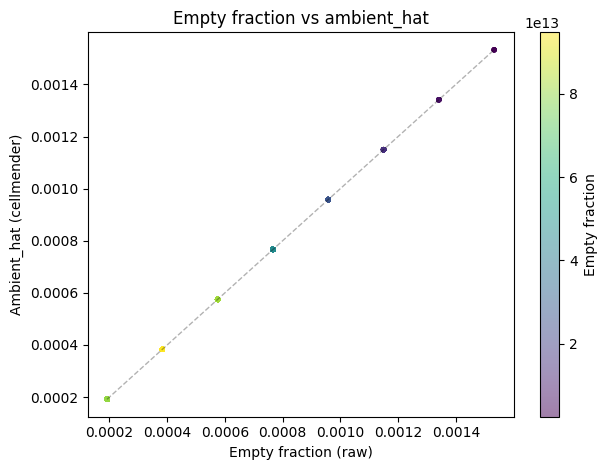

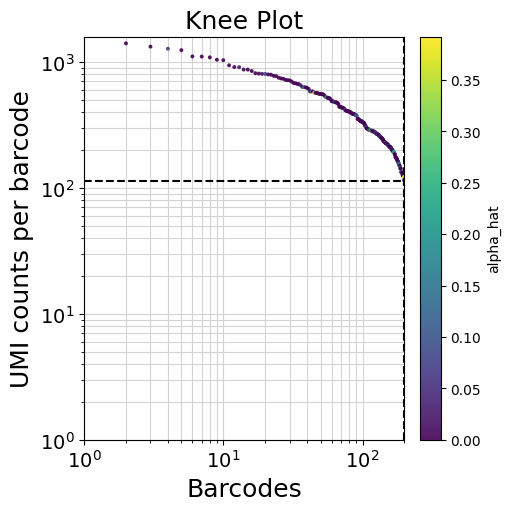

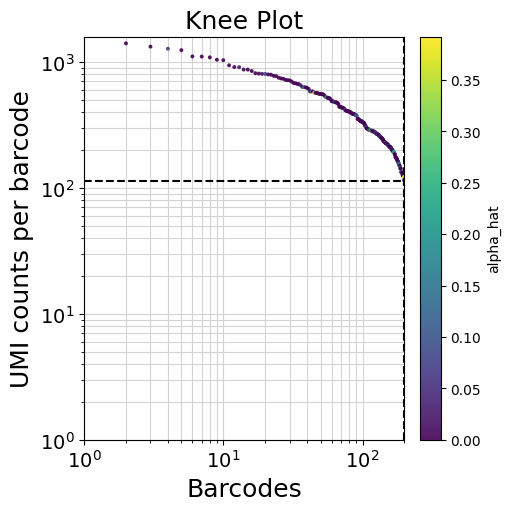

In [12]:
# plot CellMender likelihood over epochs
if os.path.exists(cellmender_log_file):
    cm_utils.plot_cellmender_likelihood_over_epochs(log_path=cellmender_log_file, show=True)

# plot ambient_hat vs empty fraction
cm_utils.plot_ambient_hat_vs_empty_fraction(adata_raw, adata_cellmender, remove_zeroes=True, lower_quantile_removed=None, upper_quantile_removed=0.99, out_path=os.path.join(out_dir, "cellmender_ambient_hat_vs_empty_fraction.png"))

# plot knee plot colored by alpha_hat
adata_denoised = adata_cellmender.copy()
adata_denoised.layers["denoised"] = adata_denoised.X.copy()
adata_denoised.X = adata_denoised.layers["raw"].copy()
cm_utils.knee_plot(adata_denoised, expected_cells=expected_cells, color_column="alpha_hat")
cm_utils.knee_plot(adata_denoised[~adata_denoised.obs["is_empty"]], expected_cells=expected_cells, color_column="alpha_hat")
adata_denoised.obs["total_counts_raw"] = np.ravel(adata_denoised.layers["raw"].sum(axis=1))
adata_denoised.obs["total_counts_denoised"] = np.ravel(adata_denoised.layers["denoised"].sum(axis=1))
adata_denoised.obs.loc[~adata_denoised.obs["is_empty"]].head(50)

## CellBender (v0.3.0)

In [13]:
%%time
if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = cellbender_ckpt.replace(f"{cellmender_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 29 μs, sys: 1 μs, total: 30 μs
Wall time: 37 μs


In [14]:
# adata_cellbender_with_empty_droplets = anndata_from_h5(adata_path_cellbender)
# adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]
adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
adata_cellbender.var_names_make_unique()
print(f"Counts are less than or equal check for CellBender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [16]:
%%time
if soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                leiden
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

01:04:43 - INFO - Adata initial shape: (208, 2000)
01:04:43 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.


01:04:43 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
01:04:43 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clustering and dimensionality reduction.
01:04:43 - INFO - Running PCA on the log-transformed data using 'pca' function. This step reduces the dimensionality of the data while retaining as much variance as possible. The number of principal components to compute is set to 25, and the SVD solver used is 'arpack'. Setting a random state ensures reproducibility of the results.
01:04:43 - INFO - Computing the neighborhood graph of cells using 'neig

Loading data from: /home/ruser/work/cellmender/notebooks/data/simulation1_small_noise/matrix_tar_files 
Loading raw count data
Loading cell-only count data
Loading extra analysis data where available
Assigning clusters...
Error in setClusters(sc, clusters) : 
  Invalid cluster specification.  See help.
Execution halted
CPU times: user 11.9 s, sys: 72.2 ms, total: 12 s
Wall time: 11 s


In [16]:
adata_soupx = cm_utils.load_adata(soupx_out_prefix)
adata_soupx.var_names_make_unique()
print(f"Counts are less than or equal check for SoupX: {cm_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [17]:
%%time
if decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {cfg["sequencing_technology"]} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

📦 Starting DecontX pipeline...
Raw matrix dir:  /home/ruser/work/cellmender/notebooks/data/simulation1_small_noise/matrix_tar_files/raw_gene_bc_matrices/genome 
Filtered matrix dir:  /home/ruser/work/cellmender/notebooks/data/simulation1_small_noise/matrix_tar_files/filtered_gene_bc_matrices/genome 
Sequencing technology:  10XV2 
Importing filtered CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: genome
Importing raw CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: genome
Standardizing cell and gene names...
Running decontX denoising...
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Tue Dec  9 09:36:22 2025 .. Analyzing all cells
Tue Dec  9 09:36:22 2025 .... Generating UMAP and estimating cell types
Tue Dec  9 09:36:26 2025 .... Estimating contamination
Tue Dec  9 09:36:26 2025 ...... Completed iteration: 10 | converge: 0

In [18]:
adata_decontx = cm_utils.load_adata(decontx_out_prefix)
adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
adata_decontx.var_names_make_unique()
print(f"Counts are less than or equal check for DecontX: {cm_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [ ]:
%%time
%env MPLBACKEND=
if adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite):
     if rerun_tools:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            -p {scar_prob} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

env: MPLBACKEND=
Loading data...
Preprocessing data...
Setting up AnnData for scAR...
Running scAR...

Training:   0%|          | 0/200 [00:00<?, ?it/s]
                                                 

Training: 100%|██████████| 200/200 [00:09<00:00, 21.96it/s, Loss=1.0063e+03]
Performing inference...
Saving results...

2025-12-09 01:41:09|INFO|setup_anndata|Use all 983 droplets.
2025-12-09 01:41:09|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
2025-12-09 01:41:09|INFO|setup_anndata|Iteration: 1
2025-12-09 01:41:09|INFO|setup_anndata|Iteration: 2
2025-12-09 01:41:09|INFO|setup_anndata|Iteration: 3
2025-12-09 01:41:09|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2025-12-09 01:41:09|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
2025-12-09 01:41:10|INFO|model|cuda will be used.
2025-12-09 01:41:10|INFO|model|Found ambient profile in AnnData.uns['ambient_profile_all']
2025-12-09 01:41:10|

In [24]:
adata_scar = None
if adata_path_scar:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cm_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for scAR: False


# Analysis

In [25]:
adata_dict = OrderedDict(
    raw=adata_raw,
    cellmender=adata_cellmender,
    cellbender=adata_cellbender,
    soupx=adata_soupx,
    decontx=adata_decontx,
    scar=adata_scar
)

for key, adata in adata_dict.items():
    print(f"{key}:\n{adata}\n\n")

raw:
AnnData object with n_obs × n_vars = 1000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size'
    var: 'ambient_profile', 'is_marker', 'empty_counts', 'empty_fraction'
    uns: 'marker_sets', 'simulation_params', 'type_profiles'
    layers: 'noise', 'real'


cellmender:
AnnData object with n_obs × n_vars = 200 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'ambient_profile', 'is_marker', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'marker_sets', 'p_hat', 'simulation_params', 'type_profiles'
    layers: 'noise', 'raw', 'real'


cellbender:
AnnData object with n_obs × n_vars = 207 × 2000
    var: 'gene_ids', 'feature_types', 'genome'


soupx:
AnnData object with n_obs × n_vars = 208 × 2000


decontx:
AnnData object with n_obs × n_vars = 208 × 2000


scar:
AnnData object with

## Simulations

cellmender Global sensitivity: 0.9986


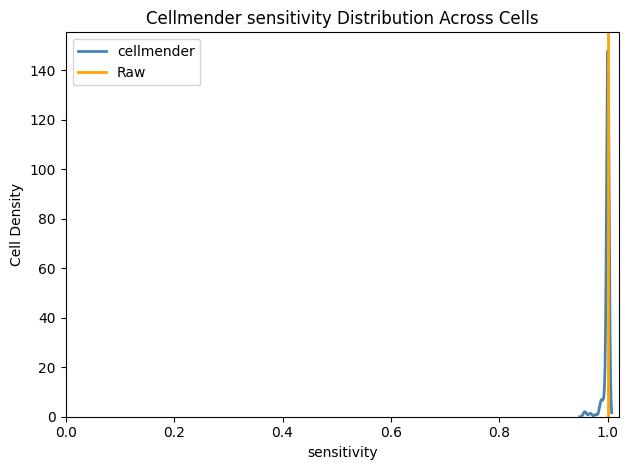

cellmender Global specificity: 0.9970


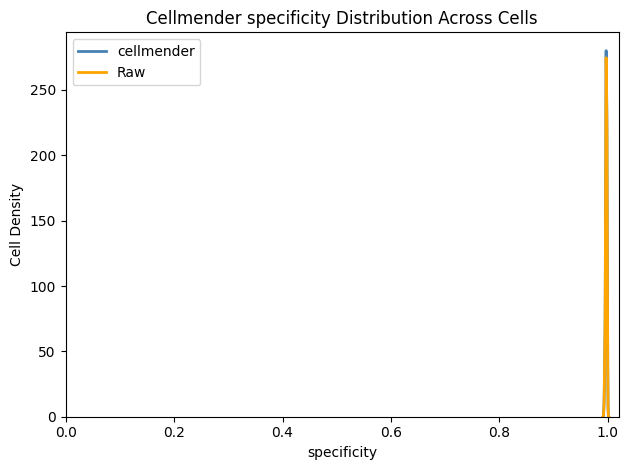

cellmender Global PPV: 0.9761


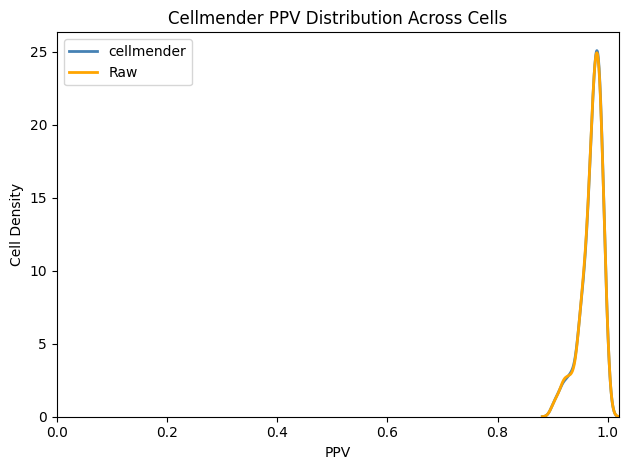

cellbender Global sensitivity: 0.9911


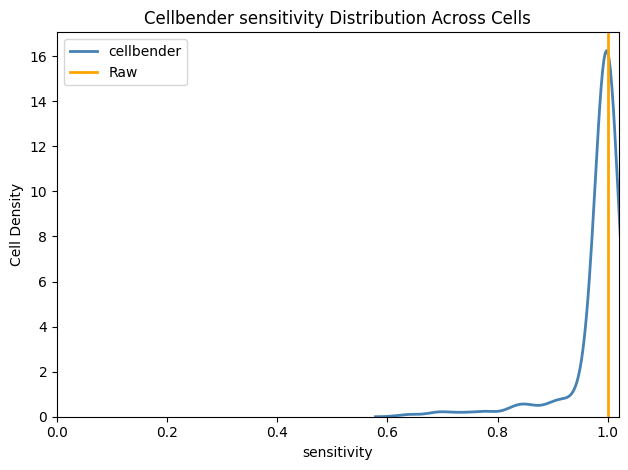

cellbender Global specificity: 0.9971


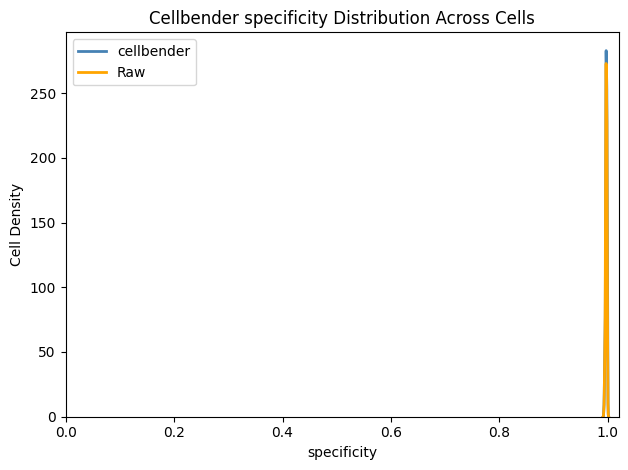

cellbender Global PPV: 0.9759


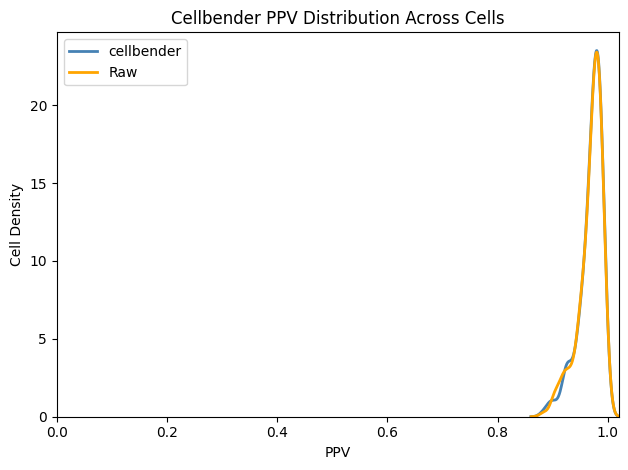

soupx Global sensitivity: 0.9993


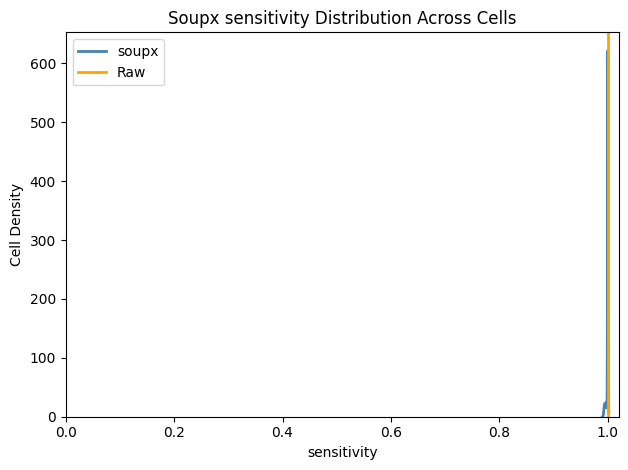

soupx Global specificity: 0.9970


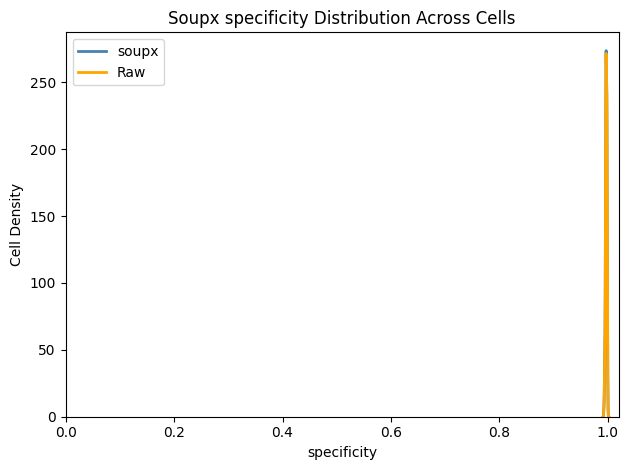

soupx Global PPV: 0.9754


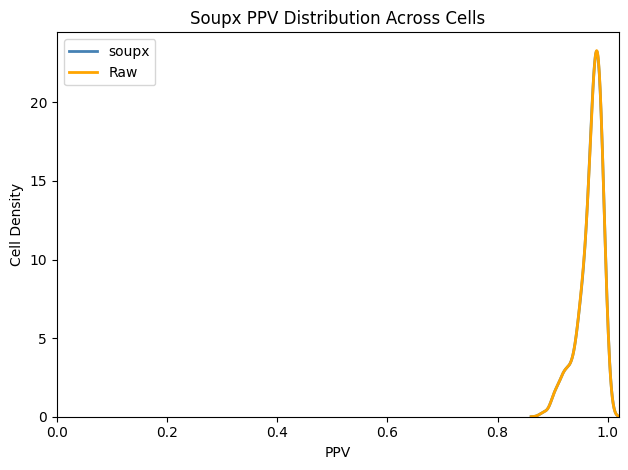

decontx Global sensitivity: 1.0000


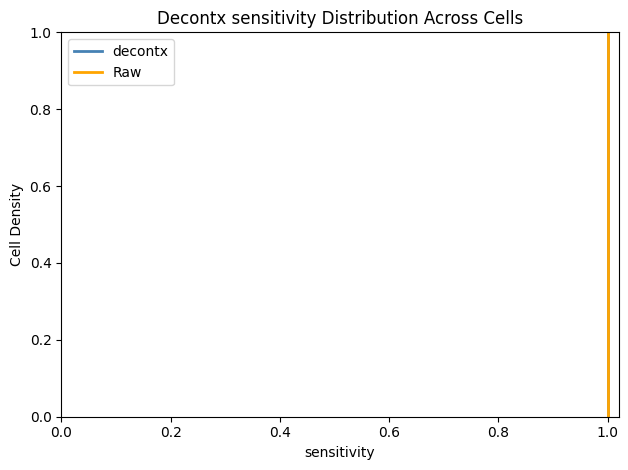

decontx Global specificity: 0.9970


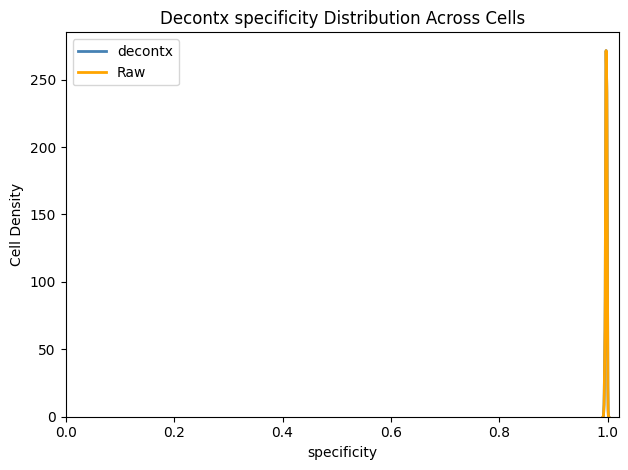

decontx Global PPV: 0.9753


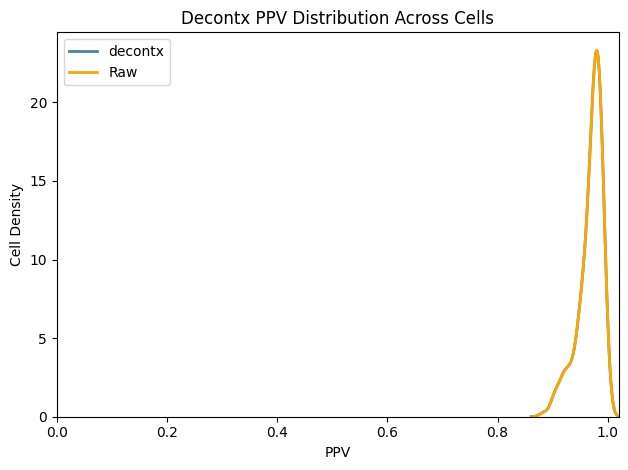

scar Global sensitivity: 0.3190


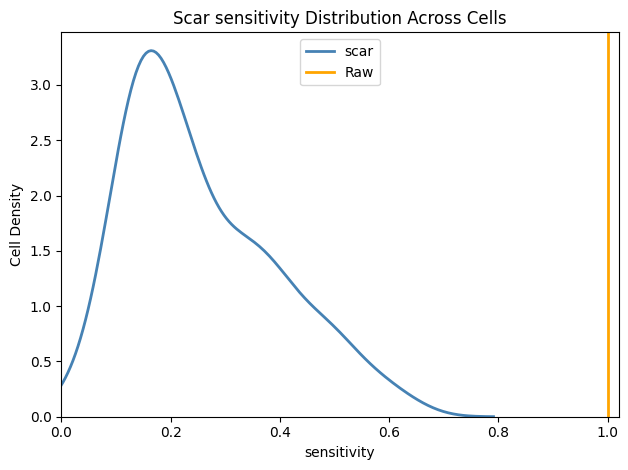

scar Global specificity: 0.9001


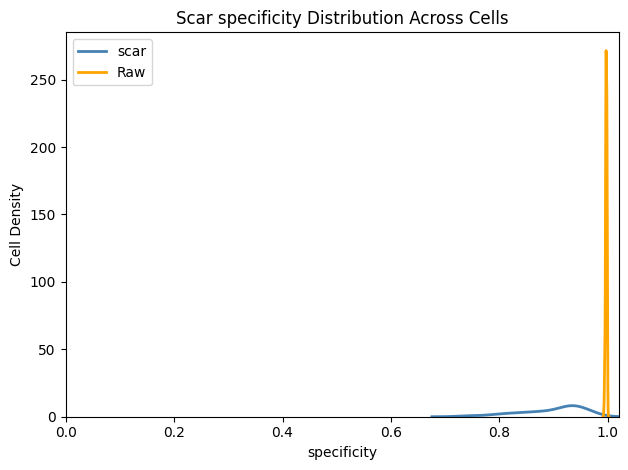

scar Global PPV: 0.2756


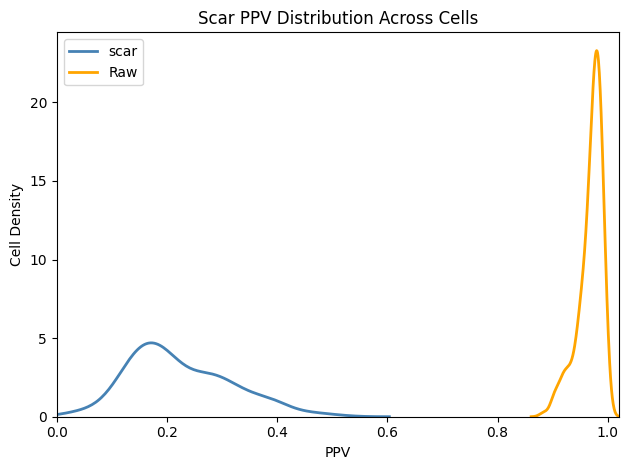

In [ ]:
if dataset_name.startswith("simulation"):
    for adata_name, adata in adata_dict.items():
        if adata_name == "raw":
            continue
            # adata = adata[~adata.obs['is_empty']].copy()
        cm_utils.evaluate_simulation_denoising(adata_processed = adata, adata_real = adata_dict["raw"], tool = adata_name, out_base = f"{out_dir}/{adata_name}_denoising_evaluation", show=True)

## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sty

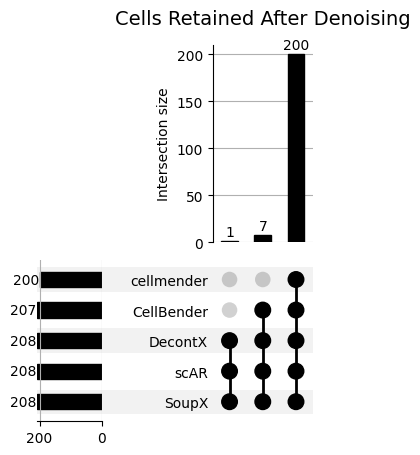

In [27]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After Denoising", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

1/15 Comparing raw vs cellmender...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


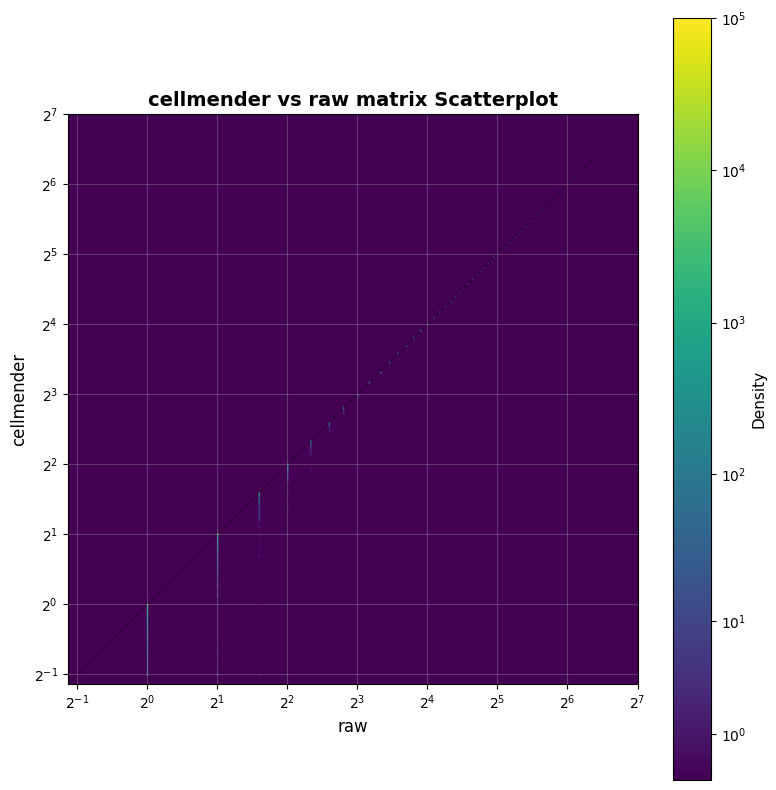

Creating scatterplot...
Calculating scatterplot...


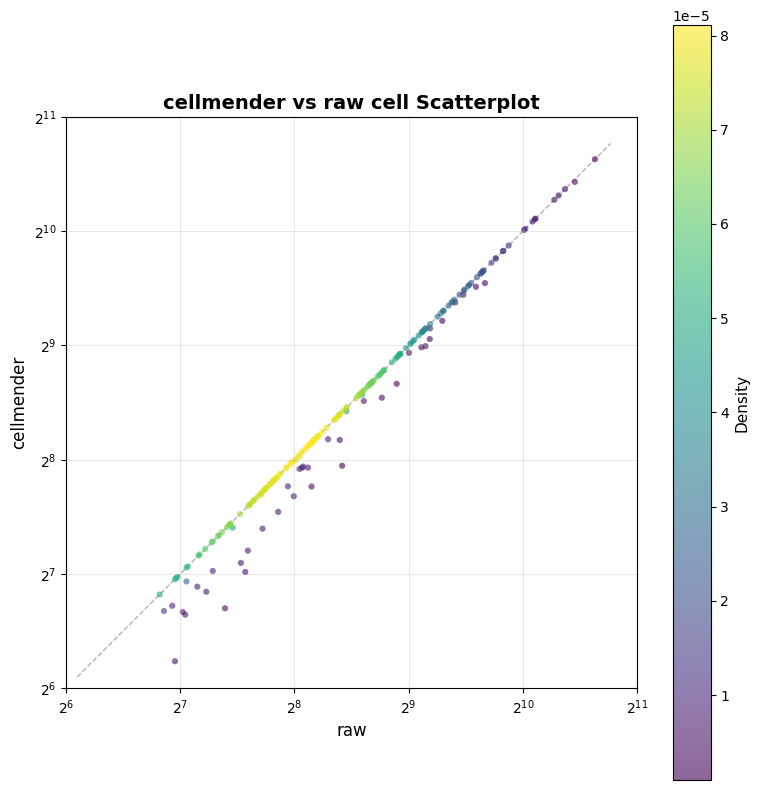

Creating scatterplot...
Calculating scatterplot...


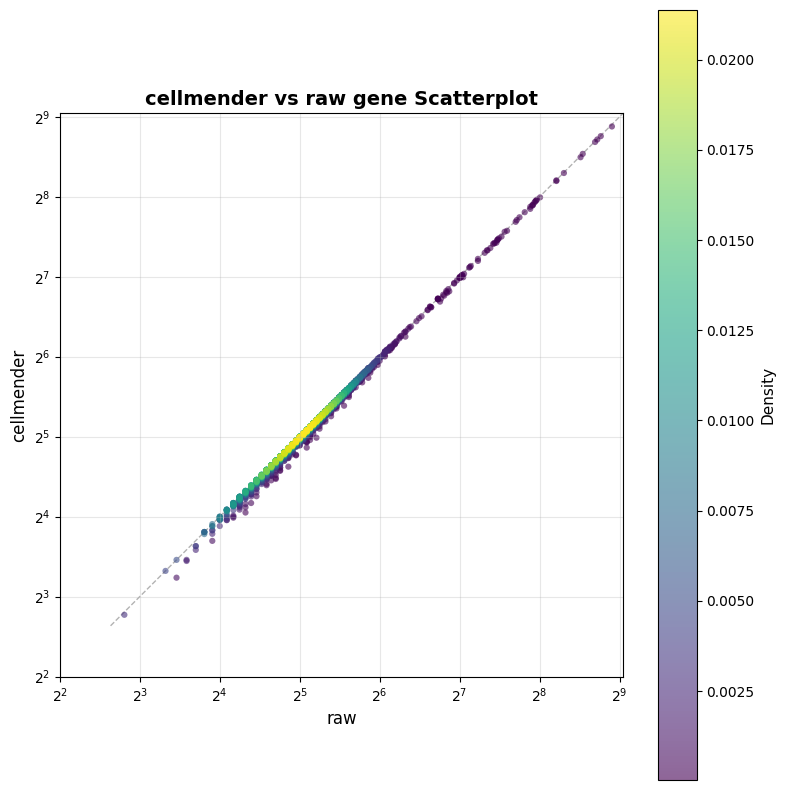

Total differences between raw and cellmender: 1,531.3711064779282


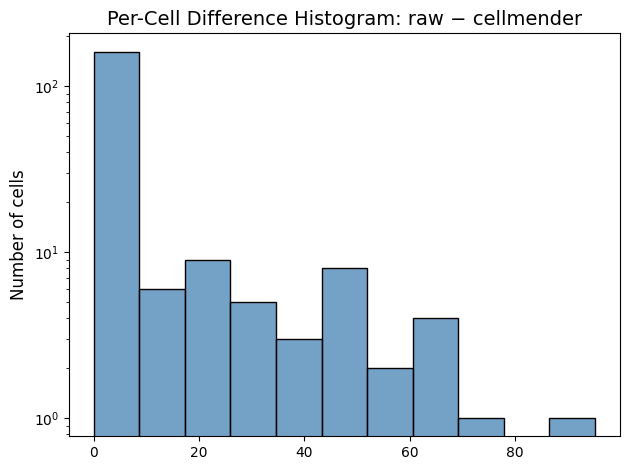

Total differences between raw and cellmender: 1,531.3711064779282


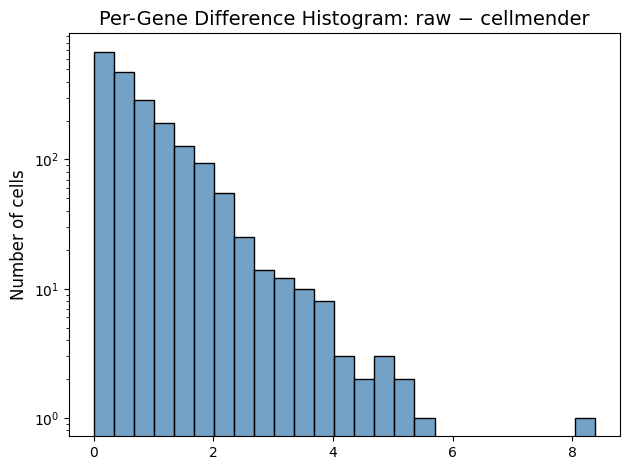

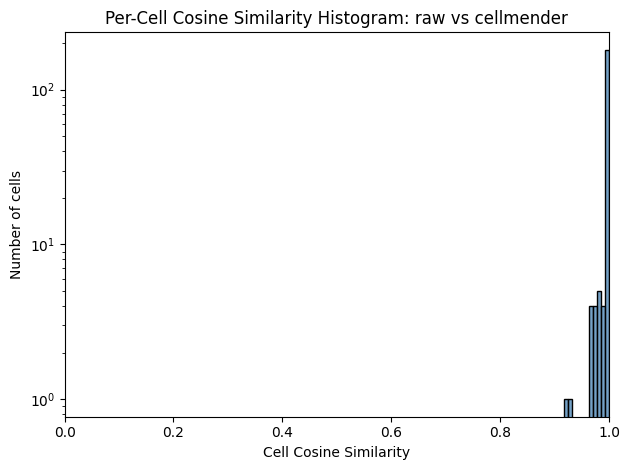

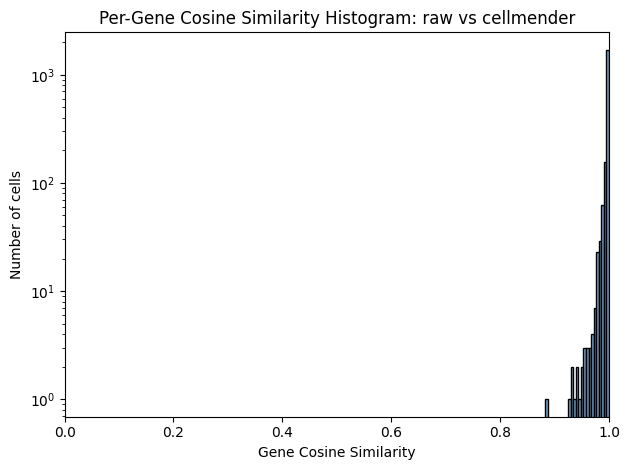

2/15 Comparing raw vs cellbender...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


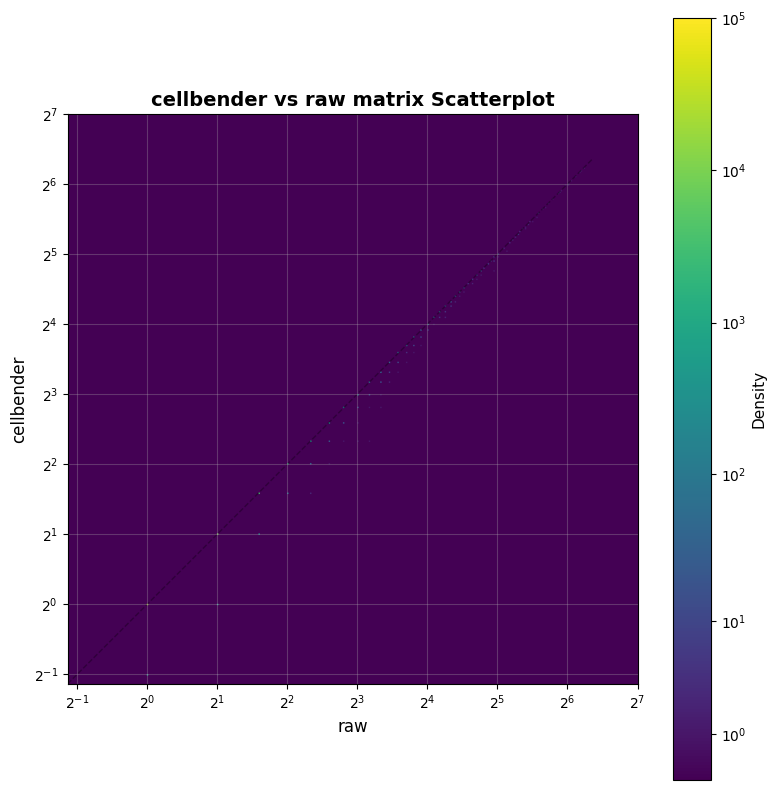

Creating scatterplot...
Calculating scatterplot...


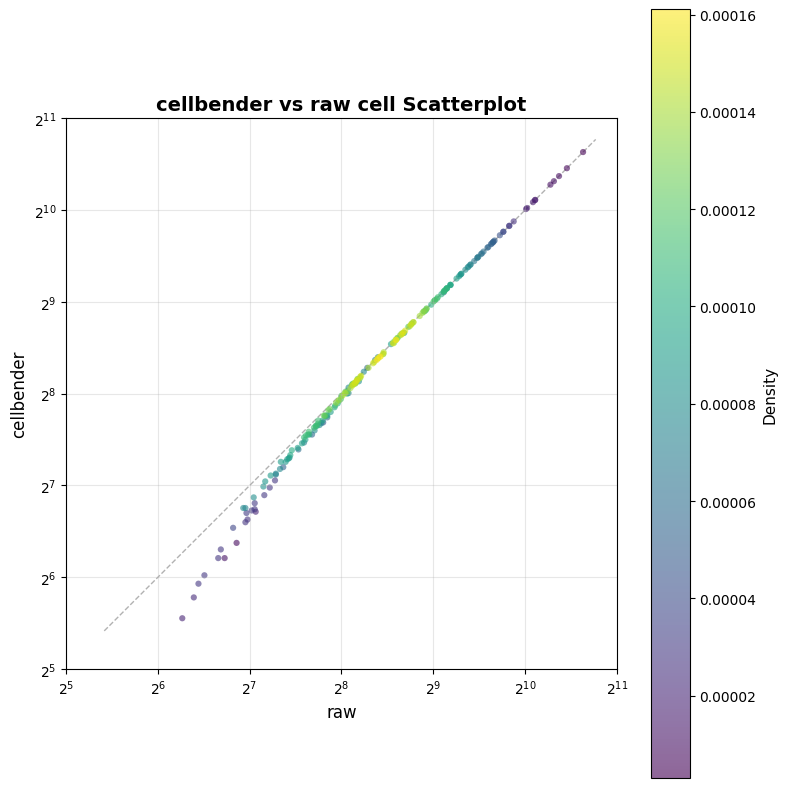

Creating scatterplot...
Calculating scatterplot...


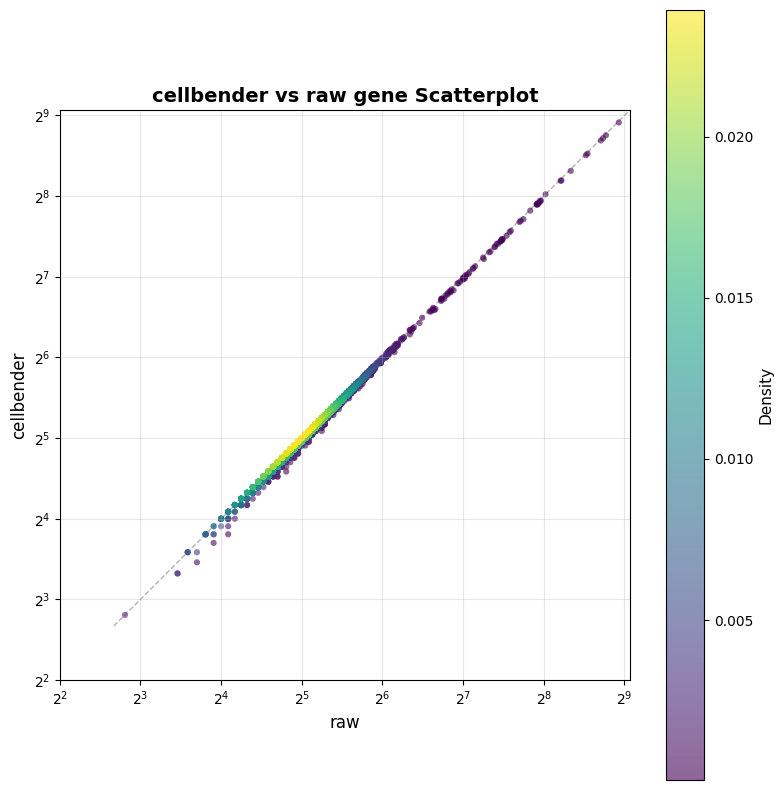

Total differences between raw and cellbender: 1,448


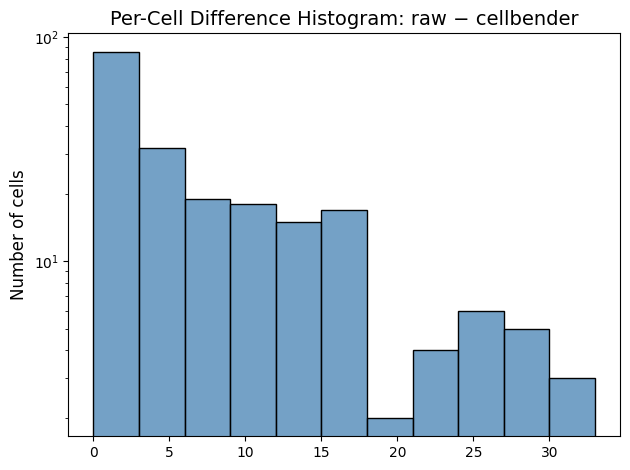

Total differences between raw and cellbender: 1,448


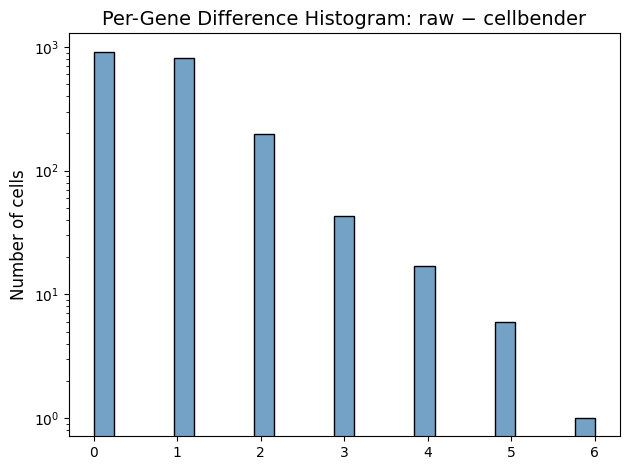

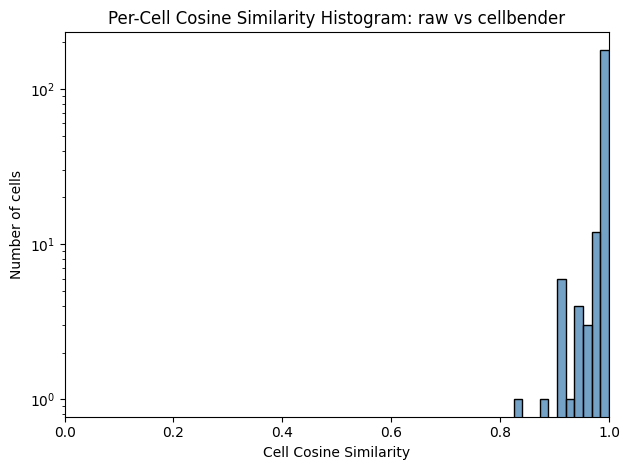

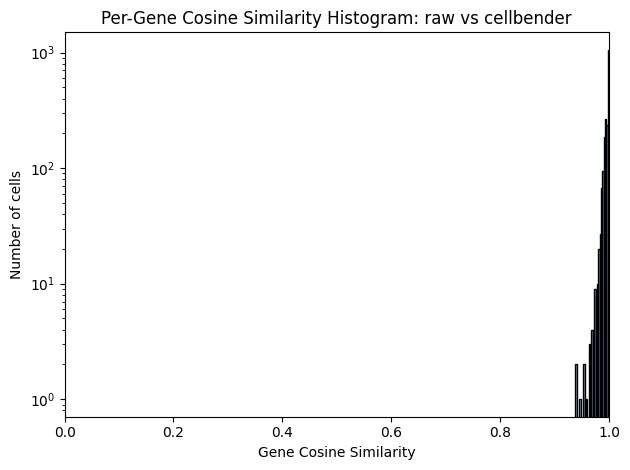

3/15 Comparing raw vs soupx...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between raw and soupx: 4,653.0
Total differences between raw and soupx: 4,653.0
4/15 Comparing raw vs decontx...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between raw and decontx: 24,250.021772496497
Total differences between raw and decontx: 24,250.021772496497
5/15 Comparing raw vs scar...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between raw and scar: 22,752
Total differences between raw and scar: 22,752
6/15 Comparing cellmender vs cellbender...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


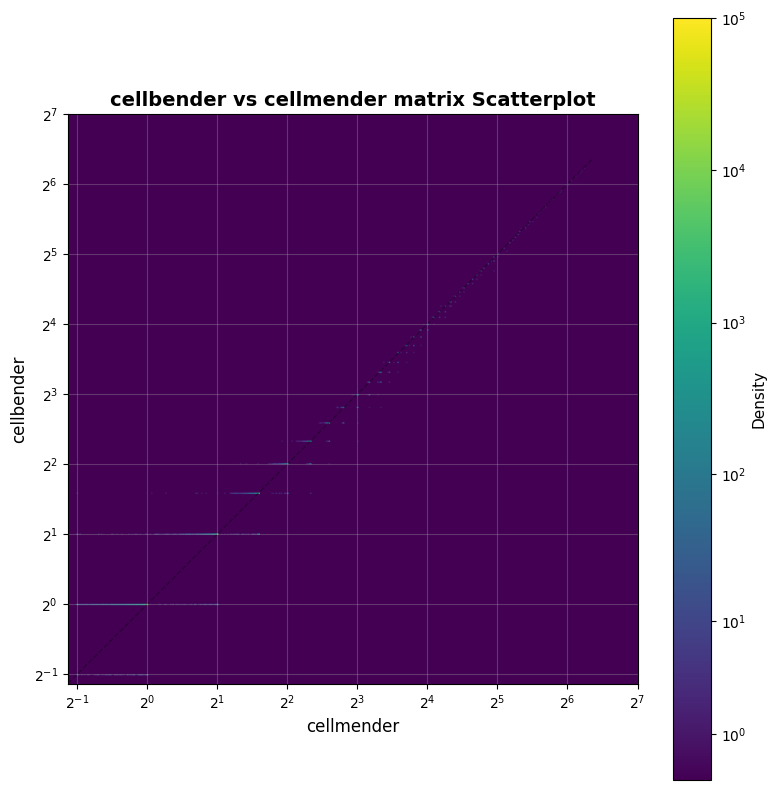

Creating scatterplot...
Calculating scatterplot...


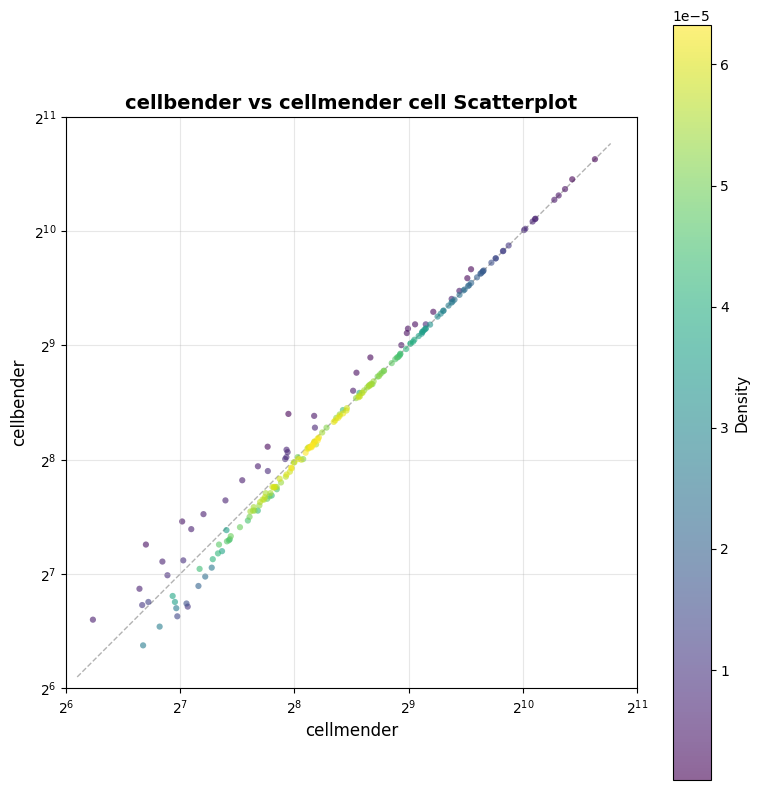

Creating scatterplot...
Calculating scatterplot...


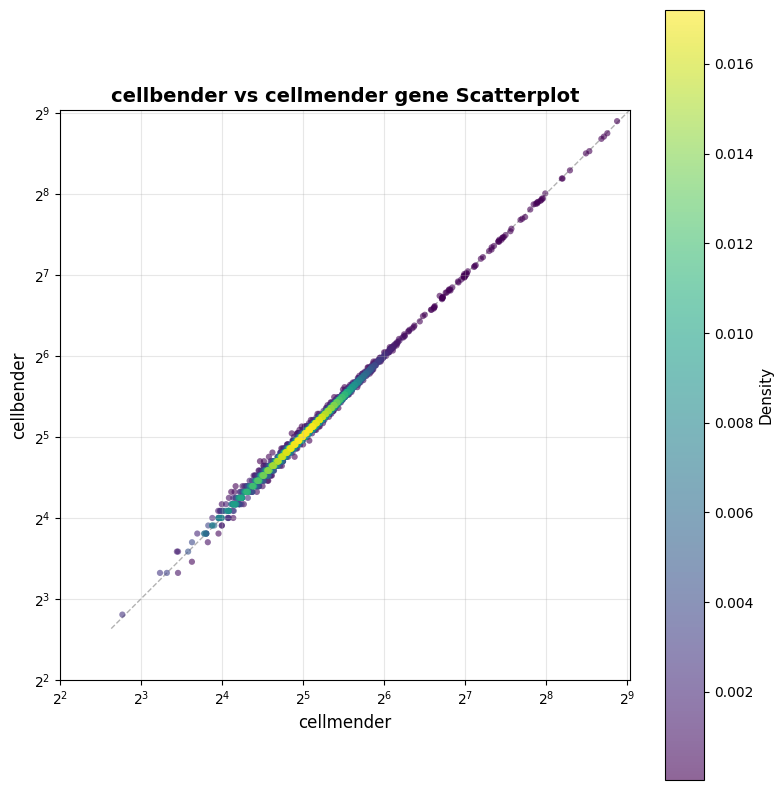

Total differences between cellmender and cellbender: -277.3711064779284


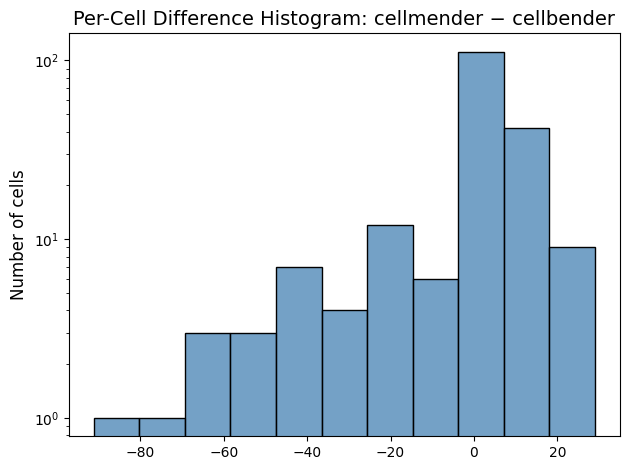

Total differences between cellmender and cellbender: -277.3711064779284


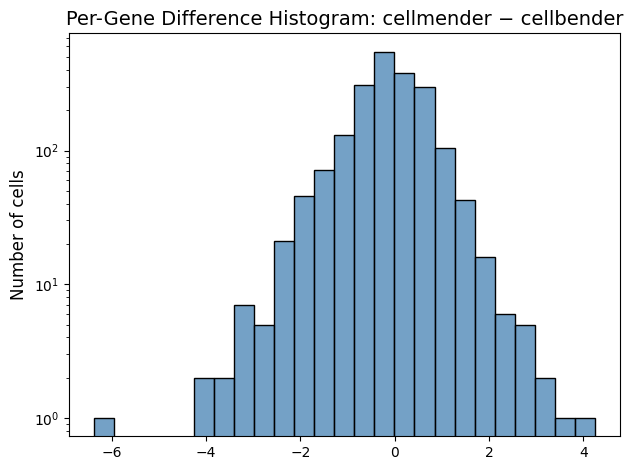

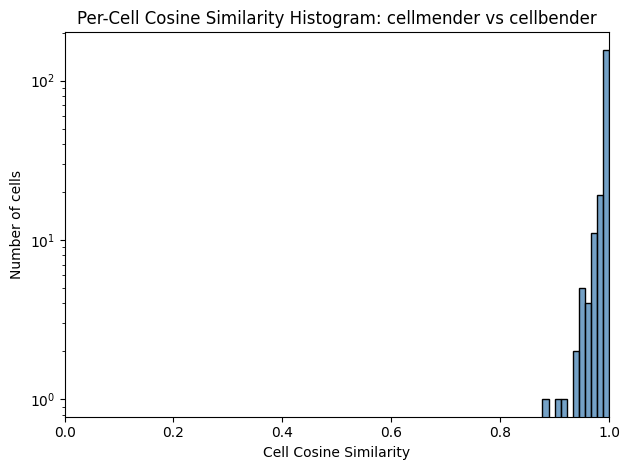

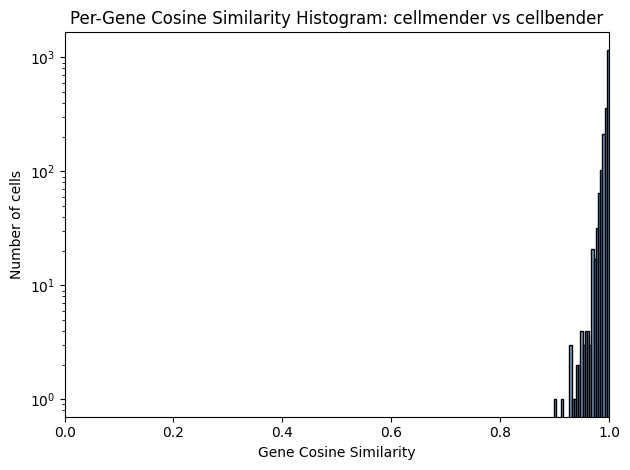

7/15 Comparing cellmender vs soupx...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between cellmender and soupx: 3,100.6758912523337
Total differences between cellmender and soupx: 3,100.6758912523337
8/15 Comparing cellmender vs decontx...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between cellmender and decontx: 22,506.42686517111
Total differences between cellmender and decontx: 22,506.42686517111
9/15 Comparing cellmender vs scar...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


...

Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between soupx and decontx: 19,597.021772496497
Total differences between soupx and decontx: 19,597.021772496497
14/15 Comparing soupx vs scar...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between soupx and scar: 18,099.0
Total differences between soupx and scar: 18,099.0
15/15 Comparing decontx vs scar...
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between decontx and scar: -1,498.0217724964978
Total differences between decontx and scar: -1,498.0217724964978


In [28]:
num_iterations = len(adata_dict) * (len(adata_dict) - 1) // 2  # n choose 2
iteration = 1
for (key1, val1), (key2, val2) in itertools.combinations(adata_dict.items(), 2):
    print(f"{iteration}/{num_iterations} Comparing {key1} vs {key2}...")
    show = (key1 in {"raw", "cellmender", "cellbender"} and key2 in {"raw", "cellmender", "cellbender"})
    # Scatterplot by matrix, cell, and gene
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_matrix_expression_scatterplot.png"), show=show)
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_cell_expression_scatterplot.png"), show=show)
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_gene_expression_scatterplot.png"), show=show)
    
    # Histogram of differences from raw by matrix, cell, and gene
    # cm_utils.plot_per_cell_difference(val1, val2, plot_type="matrix", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_matrix_absolute_difference_from_{key1}.png"))
    cm_utils.plot_per_cell_difference(val1, val2, plot_type="cell", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_cell_absolute_difference_from_{key1}.png"), show=show)
    cm_utils.plot_per_cell_difference(val1, val2, plot_type="gene", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_gene_absolute_difference_from_{key1}.png"), show=show)

    # Histogram of cosine similarity by cell and gene
    cm_utils.plot_per_cell_correlation(val1, val2, plot_type="cell", title=f"Per-Cell Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_cell_correlation.png"), show=show)
    cm_utils.plot_per_cell_correlation(val1, val2, plot_type="gene", title=f"Per-Gene Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_gene_correlation.png"), show=show)
    
    iteration += 1

In [29]:
if dataset_name.startswith("simulation"):
    sys.exit()

SystemExit: 

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Joint scatterplot of human vs. mouse counts (hgmm12k dataset only)

In [ ]:
if dataset_name == "hgmm12k":
    if "genome" not in adata_raw.obs.columns:
        adata_raw = cm_utils.identify_human_and_mouse_cells(adata_raw)
    if "genome" not in adata_cellmender.obs.columns:
        adata_cellmender.obs["genome"] = adata_raw.obs["genome"].reindex(adata_cellmender.obs_names)
    if "genome" not in adata_cellbender.obs.columns:
        adata_cellbender.obs["genome"] = adata_raw.obs["genome"].reindex(adata_cellbender.obs_names)
    if adata_soupx is not None and "genome" not in adata_soupx.obs.columns:
        adata_soupx.obs["genome"] = adata_raw.obs["genome"].reindex(adata_soupx.obs_names)
    if adata_decontx is not None and "genome" not in adata_decontx.obs.columns:
        adata_decontx.obs["genome"] = adata_raw.obs["genome"].reindex(adata_decontx.obs_names)
    if adata_scar is not None and "genome" not in adata_scar.obs.columns:
        adata_scar.obs["genome"] = adata_raw.obs["genome"].reindex(adata_scar.obs_names)
    
    doublet_cell_set = set(adata_raw.obs.index[adata_raw.obs["is_doublet"]])
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()
    for key, adata_processed in adata_dict.items():
        if key == "raw":
            continue
        cm_utils.plot_cross_species_histogram(adata_processed, processed_name=key, doublet_cell_set=doublet_cell_set, out_path_human=os.path.join(out_dir, f"{key}_human_counts_histogram.png"), out_path_mouse=os.path.join(out_dir, f"{key}_mouse_counts_histogram.png"))
        cm_utils.plot_joint_scatterplot(adata_raw_no_doublets, adata_processed, processed_name=key, marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{key}_joint_scatterplot.png"), show=True)

In [ ]:
if dataset_name == "hgmm12k":
    sys.exit()

## Alluvial plot of cluster differences

In [ ]:
adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_soupx:
    adata_soupx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cm_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_decontx:
    adata_decontx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cm_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_scar:
    adata_scar = cm_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cm_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

13:26:00 - INFO - Adata initial shape: (8381, 33694)
13:26:00 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.


13:26:00 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
13:26:00 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clustering and dimensionality reduction.
13:26:01 - INFO - Running PCA on the log-transformed data using 'pca' function. This step reduces the dimensionality of the data while retaining as much variance as possible. The number of principal components to compute is set to 25, and the SVD solver used is 'arpack'. Setting a random state ensures reproducibility of the results.
13:26:02 - INFO - Computing the neighborhood graph of cells using 'neig

In [ ]:
col_names = ["cellbender", "cellmender", "soupx", "decontx", "scAR"]
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
    display(Image(filename=os.path.join(out_dir, "alluvial_cluster.png")))
    
    cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
    display(Image(filename=os.path.join(out_dir, "alluvial_celltype.png")))

except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    reverse_map = {fine: broad for broad, fine_list in CellBender_Fig2_to_Immune_All_High_celltype_mapping.items() for fine in fine_list}
    adata_cellmender.obs["broad_celltype"] = adata_cellmender.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_soupx:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_decontx:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_scar:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

## 0 out counts below 0.5

In [ ]:
adata_cellmender = cm_utils.zero_out_low_counts(adata_cellmender, threshold=0.5)
adata_cellbender = cm_utils.zero_out_low_counts(adata_cellbender, threshold=0.5)
if adata_soupx:
    adata_soupx = cm_utils.zero_out_low_counts(adata_soupx, threshold=0.5)
if adata_decontx:
    adata_decontx = cm_utils.zero_out_low_counts(adata_decontx, threshold=0.5)
if adata_scar:
    adata_scar = cm_utils.zero_out_low_counts(adata_scar, threshold=0.5)

In [ ]:
# cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))
# cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
# if adata_soupx:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx.png"))
# if adata_decontx:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx.png"))
# if adata_scar:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

## Standardize clusters to CellBender

... storing 'broad_celltype' as categorical


CellMender Raw Data Dotplot


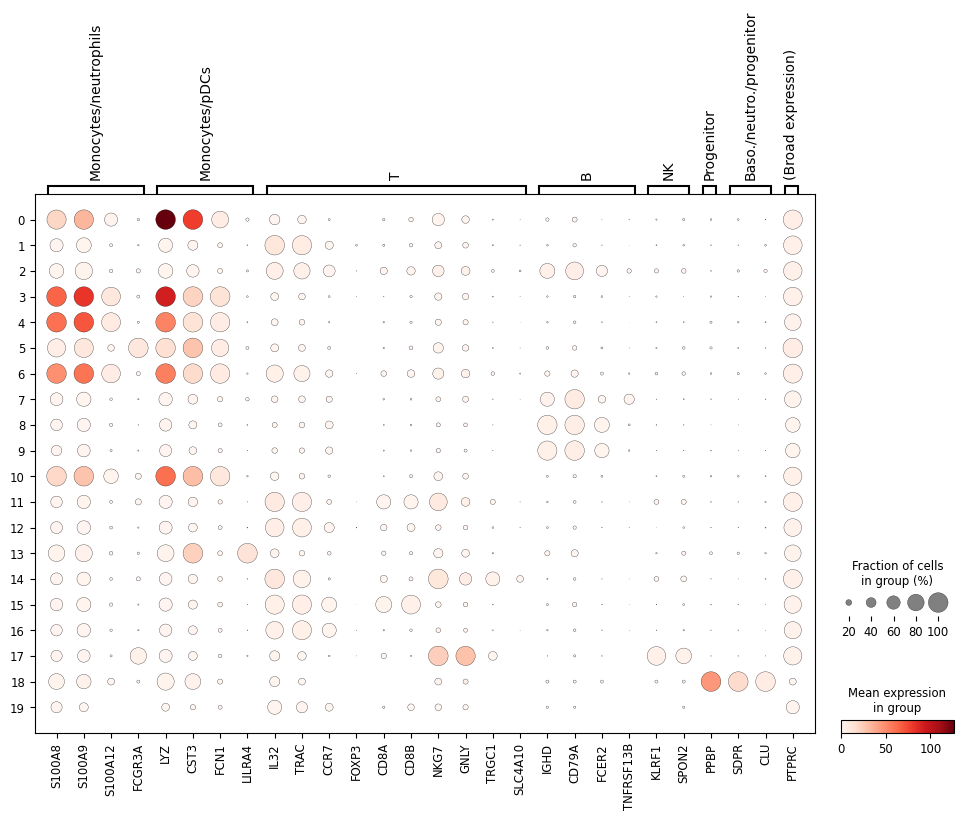

... storing 'broad_celltype' as categorical


------------------------------
CellMender Processed Data Dotplot


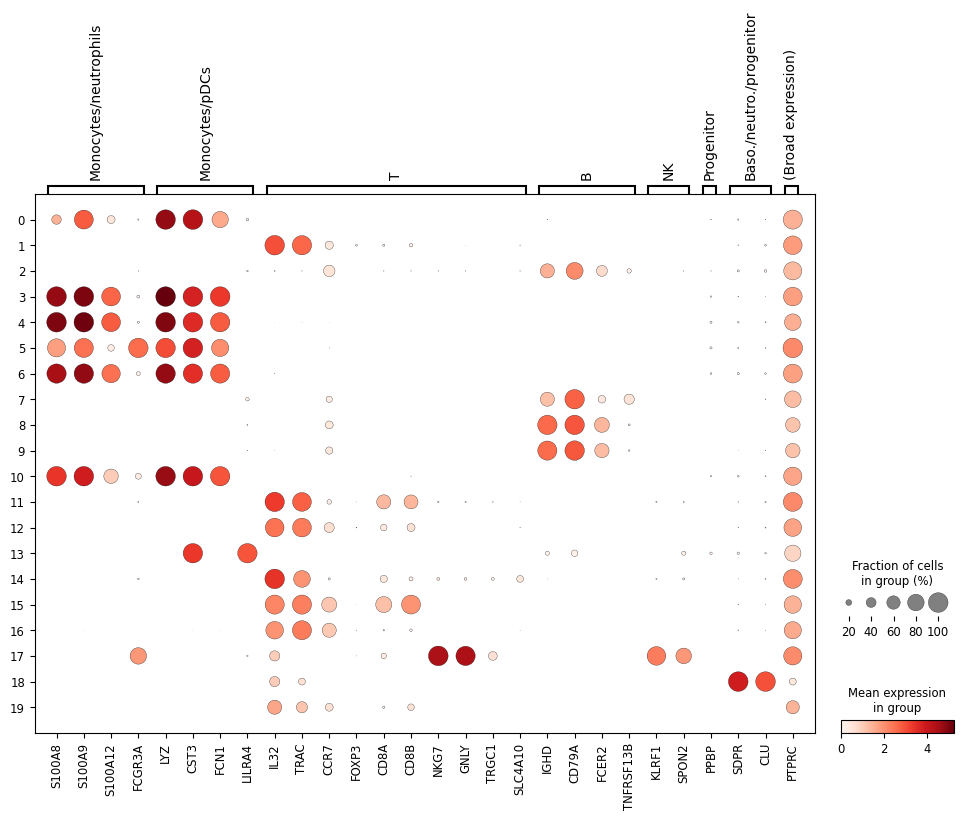

... storing 'broad_celltype' as categorical


------------------------------
CellBender Raw Data Dotplot


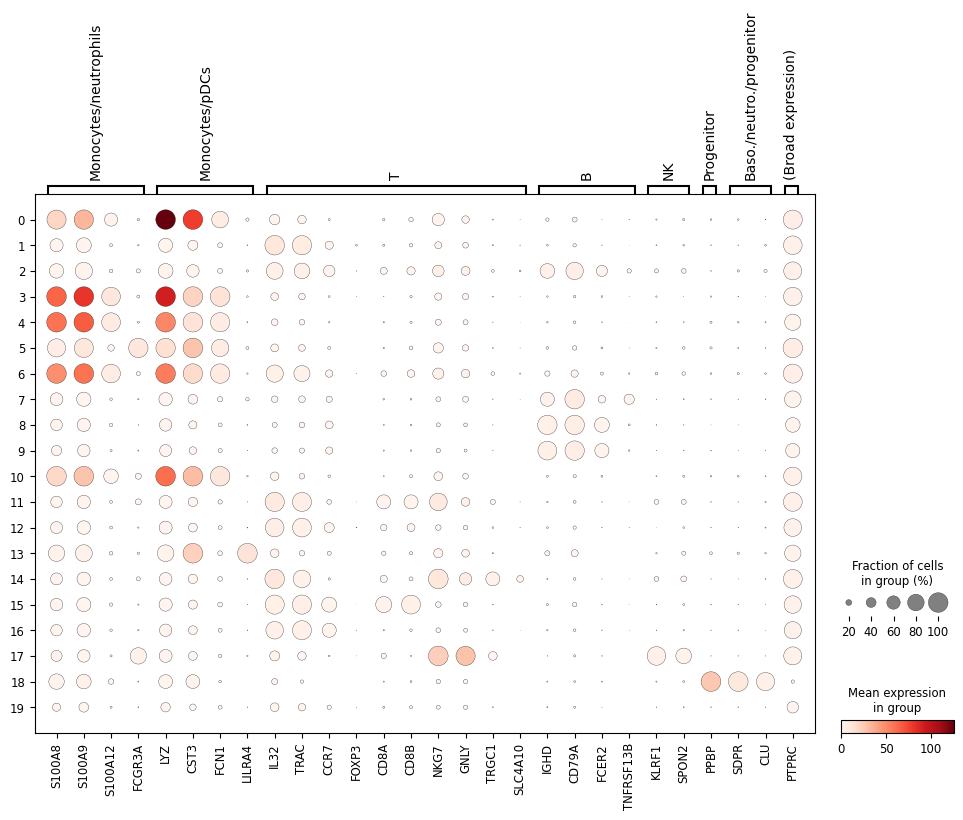

... storing 'broad_celltype' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


------------------------------
CellBender Processed Data Dotplot


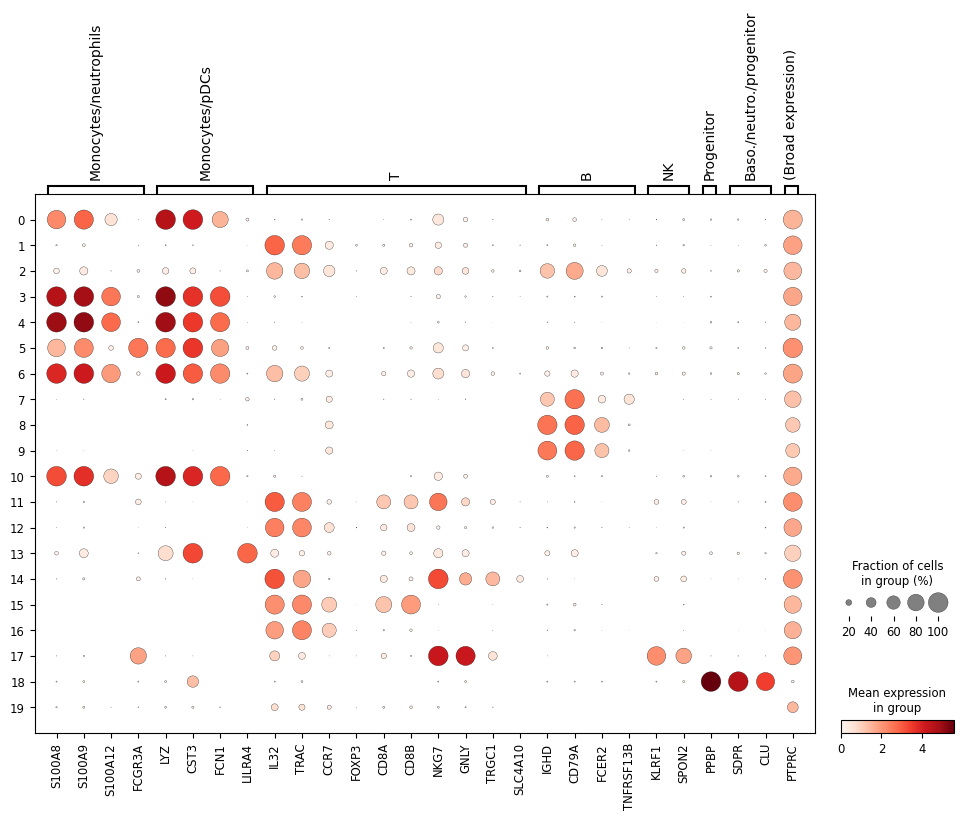

... storing 'broad_celltype' as categorical


------------------------------
SoupX Raw Data Dotplot


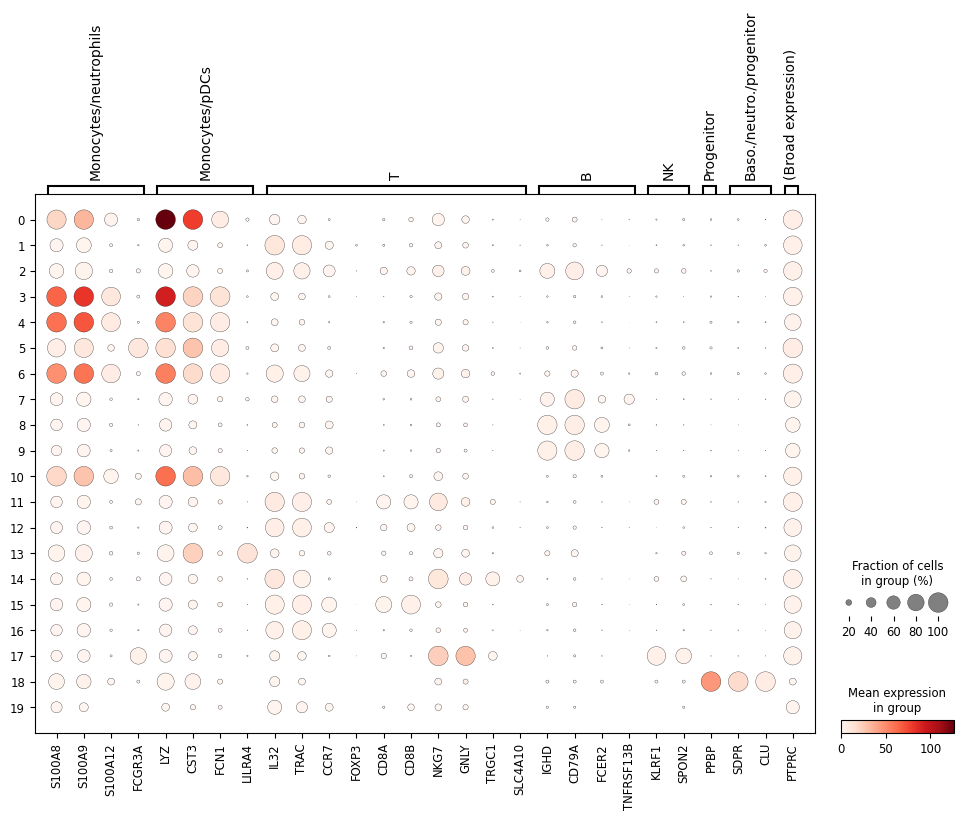

... storing 'broad_celltype' as categorical


------------------------------
SoupX Processed Data Dotplot


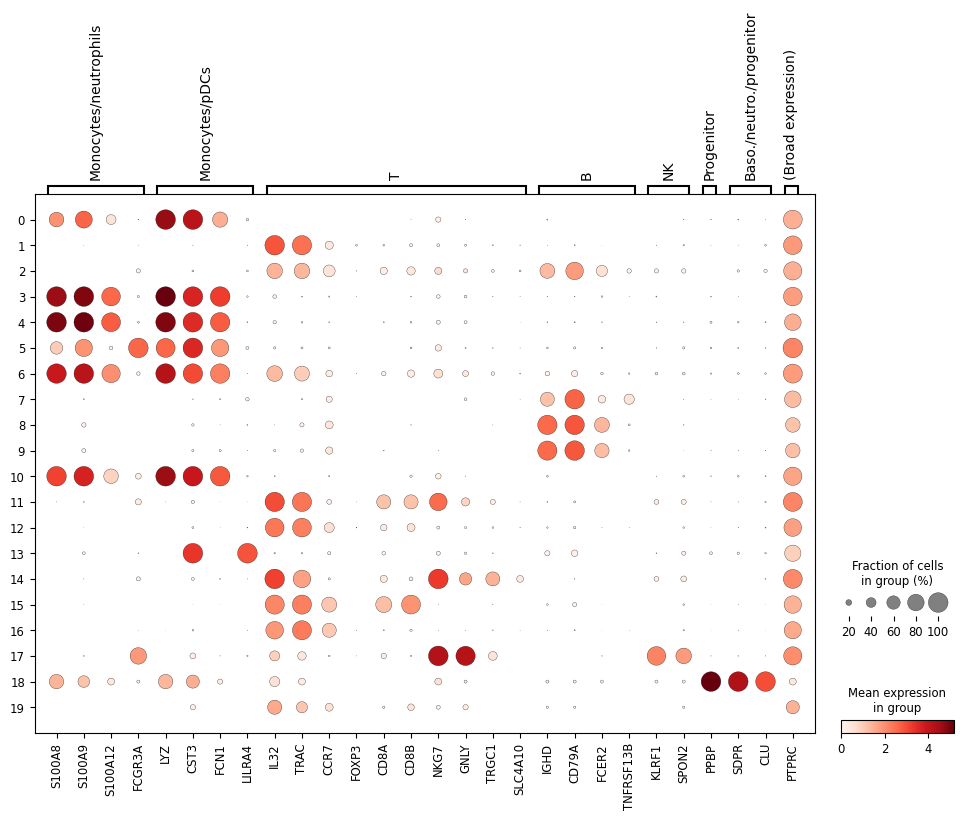

... storing 'broad_celltype' as categorical


------------------------------
DecontX Raw Data Dotplot


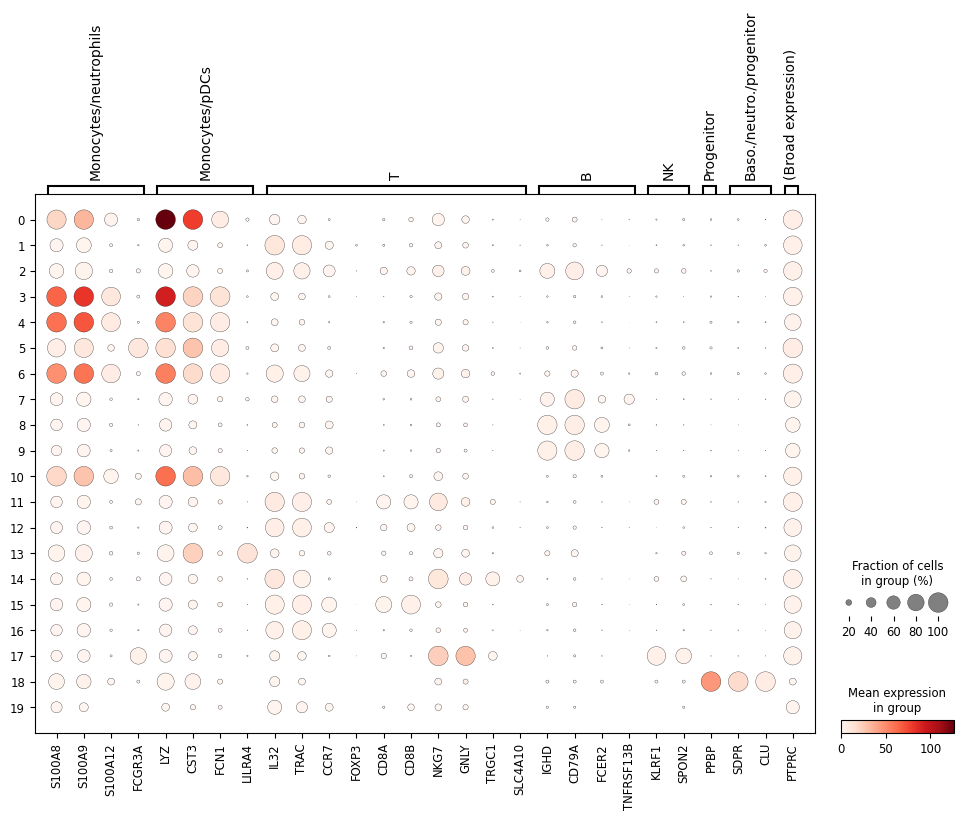

... storing 'broad_celltype' as categorical


------------------------------
DecontX Processed Data Dotplot


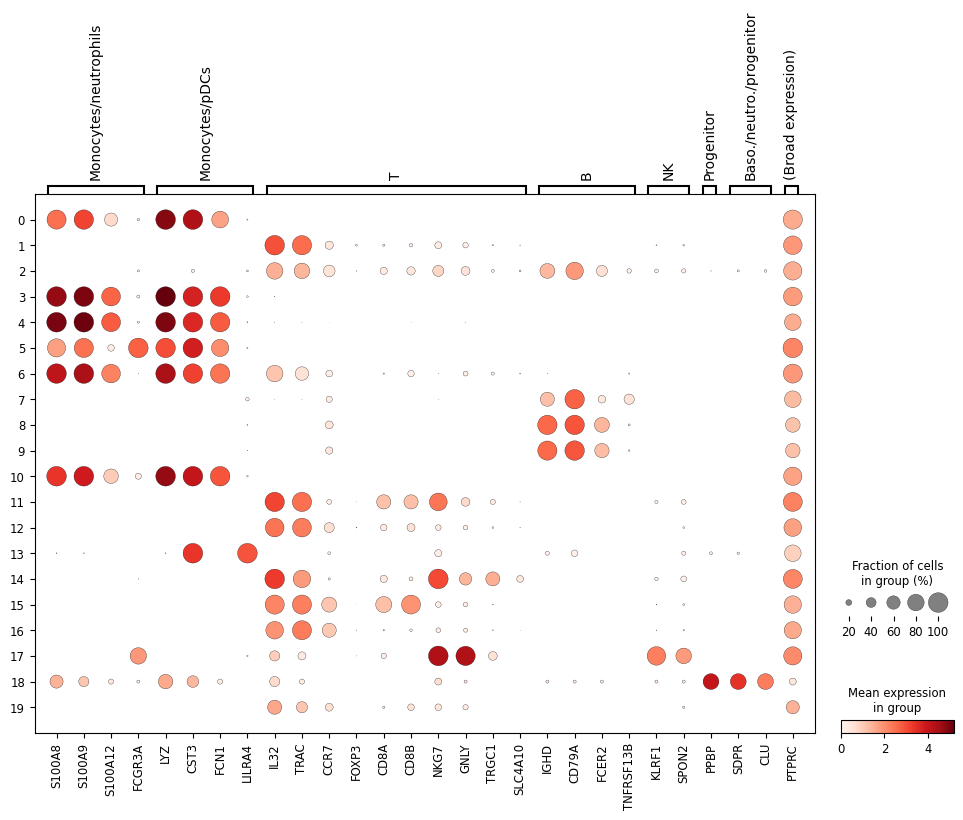

... storing 'broad_celltype' as categorical


------------------------------
scAR Raw Data Dotplot


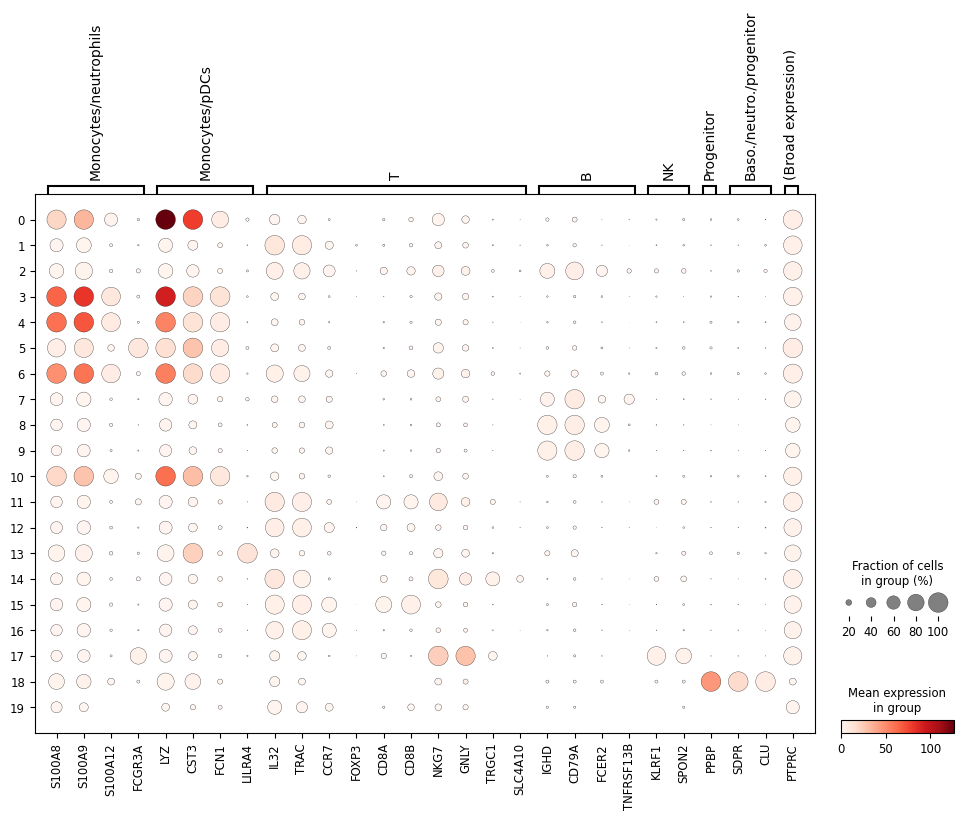

... storing 'broad_celltype' as categorical


------------------------------
scAR Processed Data Dotplot


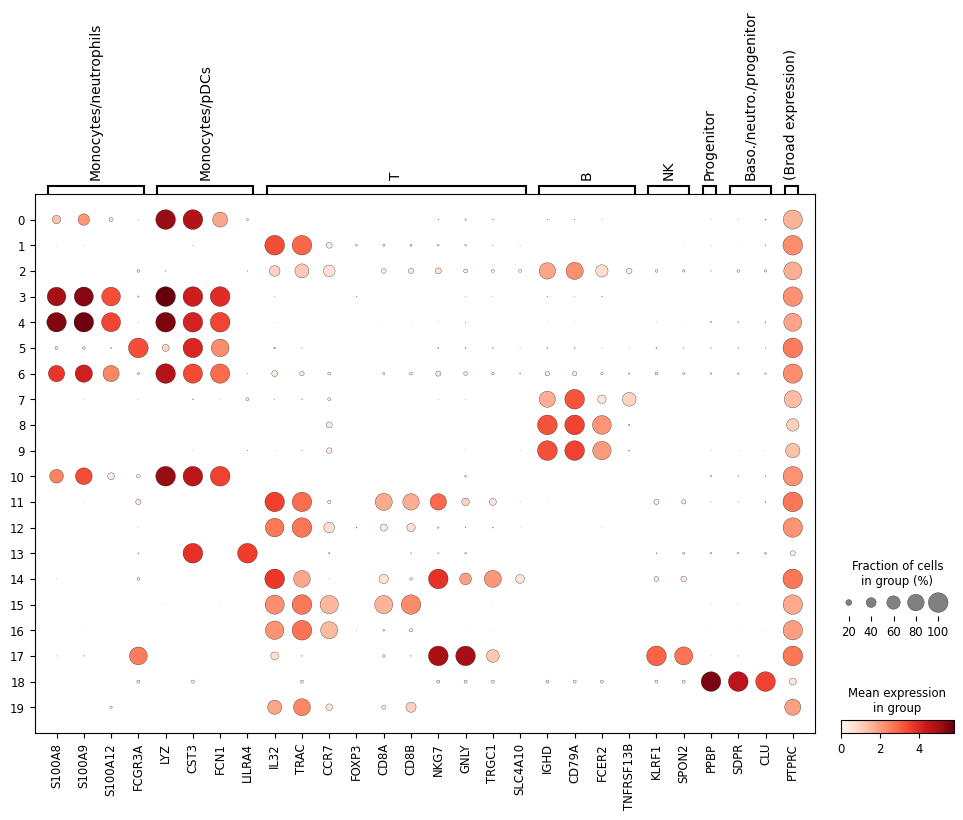

------------------------------


In [ ]:
adata_cellmender.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_cellmender.obs.index)
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender_with_cellbender_clusters.png"))

cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))

if adata_soupx:
    adata_soupx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_soupx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx_with_cellbender_clusters.png"))
if adata_decontx:
    adata_decontx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_decontx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx_with_cellbender_clusters.png"))
if adata_scar:
    adata_scar.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_scar.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar_with_cellbender_clusters.png"))

## Bonus: Number of parameters in cellmender and CellBender

In [ ]:
cellmender_parameters = cm_utils.count_cellmender_parameters(cellmender_log_file)
print(cellmender_parameters)

13:02:53 - DEBUG - Number of parameters in the cellmender model: 336,609 (u: 8, beta: 1, gamma_type: 67,048, p_k: 269,552)


In [ ]:
cellbender_parameters = cm_utils.count_cellbender_parameters(cellbender_ckpt)
print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")


=== Model Architecture (inferred from state_dict) ===
Total parameters: 31,758,725

encoder_z$$$network.0.layer.0.weight               | Shape: torch.Size([512, 15166]) | Params: 7,764,992
encoder_z$$$network.0.layer.0.bias                 | Shape: torch.Size([512])    | Params: 512
encoder_z$$$loc_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$loc_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_z$$$sig_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$sig_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_other$$$layer1.weight                      | Shape: torch.Size([512, 15170]) | Params: 7,767,040
encoder_other$$$layer1.bias                        | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.weight                  | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.bias   